In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import optimize
from scipy.special import gammaln


In [8]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
ALL_SENSORS = [f"s_{i}" for i in range(1, 22)]
WINDOW = 15
RUL_CAP = 125
RNG = np.random.default_rng(0)

In [9]:
def load(ds):
    tr = pd.read_csv(DATA_DIR / f"train_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    te = pd.read_csv(DATA_DIR / f"test_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    rul = pd.read_csv(DATA_DIR / f"RUL_{ds}.txt", header=None, names=["RUL"]).squeeze("columns").values
    return tr, te, rul
 
 
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum()
 
 
def metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "NASA_score": float(nasa_score(y_true, y_pred)),
    }
 
 
def assign_regime(df, kmeans):
    if kmeans is None:
        return np.zeros(len(df), dtype=int)
    return kmeans.predict(df[["op_1", "op_2", "op_3"]].values)
 
 
def select_informative_sensors(train_df, regime_col, thr=1e-3):
    """Keep sensors with within-regime std > thr in at least one regime."""
    kept = []
    for s in ALL_SENSORS:
        within = train_df.groupby(regime_col)[s].std().fillna(0)
        if within.max() > thr:
            kept.append(s)
    return kept
 
 
def fit_regime_stats(train_df, sensors, regime_col):
    """Return dict regime -> (mean_vec, std_vec) from train data only."""
    stats = {}
    for r, g in train_df.groupby(regime_col):
        mu = g[sensors].mean().values
        sd = g[sensors].std().replace(0, 1).values
        stats[r] = (mu, sd)
    return stats
 
 
def normalize_by_regime(df, sensors, regime_col, stats):
    out = df[sensors].values.astype(float).copy()
    r = df[regime_col].values
    for reg, (mu, sd) in stats.items():
        mask = r == reg
        if mask.any():
            out[mask] = (out[mask] - mu) / sd
    return pd.DataFrame(out, columns=[f"{s}_n" for s in sensors], index=df.index)
 
 
def build_features(df, sensors, normalized=True, stats=None, regime_col="regime"):
    if normalized:
        norm = normalize_by_regime(df, sensors, regime_col, stats)
        df = pd.concat([df[["unit", "cycle", regime_col]], norm], axis=1)
        feat_sensors = [f"{s}_n" for s in sensors]
    else:
        df = df[["unit", "cycle", regime_col] + sensors].copy()
        feat_sensors = sensors
 
    g = df.groupby("unit")[feat_sensors]
    roll = g.rolling(WINDOW, min_periods=1)
    parts = [df[["unit", "cycle", regime_col] + feat_sensors].reset_index(drop=True)]
    parts.append(roll.mean().reset_index(level=0, drop=True).add_suffix("_m").reset_index(drop=True))
    parts.append(roll.std().fillna(0).reset_index(level=0, drop=True).add_suffix("_sd").reset_index(drop=True))
 
    # Fast approximate slope: (x_t - x_{t-w+1}) / (w-1), computed per unit.
    # Equivalent up to a constant factor to the full least-squares slope over a
    # monotonically-indexed window, which is what rolling-apply(polyfit) produced.
    shifted = df.groupby("unit")[feat_sensors].shift(WINDOW - 1)
    sl = ((df[feat_sensors] - shifted) / (WINDOW - 1)).fillna(0).add_suffix("_sl").reset_index(drop=True)
    parts.append(sl)
    return pd.concat(parts, axis=1)
 
 
def run_experiment(ds, n_regimes, normalized=True, use_regime_feature=True, verbose=True):
    train_raw, test_raw, rul_true = load(ds)
 
    # ---- regime assignment ----
    if n_regimes == 1:
        km = None
        train_raw = train_raw.assign(regime=0)
        test_raw = test_raw.assign(regime=0)
    else:
        km = KMeans(n_clusters=n_regimes, n_init=10, random_state=0)
        km.fit(train_raw[["op_1", "op_2", "op_3"]].values)
        train_raw = train_raw.assign(regime=km.labels_)
        test_raw = test_raw.assign(regime=assign_regime(test_raw, km))
 
    sensors = select_informative_sensors(train_raw, "regime")
    if verbose:
        print(f"  [{ds}] {n_regimes} regime(s), {len(sensors)} informative sensors")
 
    stats = fit_regime_stats(train_raw, sensors, "regime") if normalized else None
    X_tr_df = build_features(train_raw, sensors, normalized=normalized, stats=stats)
    X_tr_df["RUL"] = (train_raw.groupby("unit").cycle.transform("max") - train_raw.cycle).clip(upper=RUL_CAP).values
 
    exclude = ["unit", "cycle", "RUL"]
    cat_features_arg = ["regime"]
    if not use_regime_feature:
        exclude.append("regime")
        cat_features_arg = None
    feature_cols = [c for c in X_tr_df.columns if c not in exclude]
 
    # 20%-of-units held-out val
    all_units = X_tr_df["unit"].unique()
    val_u = RNG.choice(all_units, size=max(20, len(all_units) // 5), replace=False)
    is_val = X_tr_df["unit"].isin(val_u).values
 
    X_tr_df["regime"] = X_tr_df["regime"].astype(int)
    X_tr = X_tr_df.loc[~is_val, feature_cols]
    y_tr = X_tr_df.loc[~is_val, "RUL"].values
    X_val = X_tr_df.loc[is_val, feature_cols]
    y_val = X_tr_df.loc[is_val, "RUL"].values
 
    model = CatBoostRegressor(
        iterations=1000, learning_rate=0.08, depth=5,
        loss_function="RMSE", eval_metric="RMSE",
        early_stopping_rounds=40, random_seed=42, verbose=False,
        cat_features=cat_features_arg,
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
 
    # Official test set: last observation per unit
    X_te_df = build_features(test_raw, sensors, normalized=normalized, stats=stats)
    X_te_df["regime"] = X_te_df["regime"].astype(int)
    last = X_te_df.groupby("unit").tail(1).sort_values("unit")
    X_te = last[feature_cols]
    preds = np.clip(model.predict(X_te), 0, None)
 
    return {
        "model": model,
        "metrics": metrics(rul_true, preds),
        "preds": preds,
        "y_true": rul_true,
        "n_features": len(feature_cols),
        "n_sensors": len(sensors),
        "feature_cols": feature_cols,
        "best_iter": model.get_best_iteration(),
    }

In [10]:
def train_and_predict(ds, n_regimes):
    train_raw, test_raw, rul_true = load(ds)
    if n_regimes == 1:
        train_raw = train_raw.assign(regime=0)
        test_raw = test_raw.assign(regime=0)
        km = None
    else:
        km = KMeans(n_clusters=n_regimes, n_init=10, random_state=0).fit(
            train_raw[["op_1", "op_2", "op_3"]].values)
        train_raw = train_raw.assign(regime=km.labels_)
        test_raw = test_raw.assign(regime=km.predict(test_raw[["op_1", "op_2", "op_3"]].values))
 
    sensors = select_informative_sensors(train_raw, "regime")
    stats = fit_regime_stats(train_raw, sensors, "regime")
    Xtr = build_features(train_raw, sensors, normalized=True, stats=stats)
    Xtr["regime"] = Xtr["regime"].astype(int)
    ytr = (train_raw.groupby("unit").cycle.transform("max") - train_raw.cycle).clip(upper=RUL_CAP).values
 
    fcols = [c for c in Xtr.columns if c not in ("unit", "cycle")]
    all_u = Xtr["unit"].unique()
    val_u = RNG.choice(all_u, size=max(20, len(all_u) // 5), replace=False)
    is_val = Xtr["unit"].isin(val_u).values
 
    model = CatBoostRegressor(
        iterations=1500, learning_rate=0.05, depth=6,
        loss_function="RMSE", eval_metric="RMSE",
        early_stopping_rounds=50, random_seed=42, verbose=False,
        cat_features=["regime"],
    )
    model.fit(Xtr.loc[~is_val, fcols], ytr[~is_val],
              eval_set=(Xtr.loc[is_val, fcols], ytr[is_val]))
 
    Xte = build_features(test_raw, sensors, normalized=True, stats=stats)
    Xte["regime"] = Xte["regime"].astype(int)
    last = Xte.groupby("unit").tail(1).sort_values("unit")
    preds = np.clip(model.predict(last[fcols]), 0, None)
 
    last_cycles = test_raw.groupby("unit").cycle.max().values
    total_life = last_cycles + rul_true
    return {
        "preds": preds, "y_true": rul_true,
        "last_regime": last["regime"].values,
        "total_life": total_life, "last_cycle": last_cycles,
        "metrics": metrics(rul_true, preds),
    }


In [11]:
# ============= Train both =============
print("Training FD002 (iter=1500, depth=6)...")
r2 = train_and_predict("FD002", 6)
print(f"  FD002  RMSE={r2['metrics']['RMSE']:.2f}  NASA={r2['metrics']['NASA_score']:.0f}")
 
print("Training FD004 (iter=1500, depth=6)...")
r4 = train_and_predict("FD004", 6)
print(f"  FD004  RMSE={r4['metrics']['RMSE']:.2f}  NASA={r4['metrics']['NASA_score']:.0f}")

Training FD002 (iter=1500, depth=6)...
  FD002  RMSE=28.97  NASA=11995
Training FD004 (iter=1500, depth=6)...
  FD004  RMSE=29.88  NASA=7945


In [12]:
# ============= Per-regime error breakdown =============
def per_regime_breakdown(r, ds):
    df = pd.DataFrame({
        "true": r["y_true"], "pred": r["preds"],
        "regime": r["last_regime"],
        "last_cycle": r["last_cycle"], "total_life": r["total_life"],
    })
    df["err"] = df.pred - df.true
    df["abs_err"] = df.err.abs()
    print(f"\n=== {ds} — breakdown by REGIME of last observation ===")
    summary = df.groupby("regime").agg(
        n=("true", "size"),
        rmse=("err", lambda e: np.sqrt((e ** 2).mean())),
        mae=("abs_err", "mean"),
        mean_err=("err", "mean"),
        mean_true=("true", "mean"),
    ).round(2)
    print(summary.to_string())
    return df, summary

In [13]:
df2, sum2 = per_regime_breakdown(r2, "FD002")
df4, sum4 = per_regime_breakdown(r4, "FD004")


=== FD002 — breakdown by REGIME of last observation ===
         n   rmse    mae  mean_err  mean_true
regime                                       
0       69  24.63  16.46     -5.78      69.88
1       39  27.71  17.54     -6.09      83.05
2       42  32.58  24.34     -7.89      91.74
3       41  32.16  22.05     -7.09      79.41
4       36  29.31  21.15     -9.67      88.97
5       32  29.38  20.76    -11.84      82.94

=== FD004 — breakdown by REGIME of last observation ===
         n   rmse    mae  mean_err  mean_true
regime                                       
0       64  31.64  23.78     -6.86      93.02
1       33  33.09  26.12     -8.45      87.85
2       43  30.62  23.25     -7.77      86.42
3       30  30.36  22.74    -10.75      87.87
4       39  24.91  18.25     -2.66      77.72
5       39  27.30  20.34     -4.02      82.82


In [14]:
def weibull_pdf(t, beta, eta):
    return (beta / eta) * (t / eta) ** (beta - 1) * np.exp(-(t / eta) ** beta)

In [15]:
def em_weibull_mixture(x, K=2, n_iter=200, tol=1e-6, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    # Init by splitting at median
    med = np.median(x)
    init_mask = x < med
    betas = np.array([3.0, 3.0])
    etas = np.array([np.mean(x[init_mask]) / np.exp(gammaln(1 + 1/3)),
                     np.mean(x[~init_mask]) / np.exp(gammaln(1 + 1/3))])
    pis = np.array([init_mask.mean(), 1 - init_mask.mean()])
 
    prev_ll = -np.inf
    for it in range(n_iter):
        # E step
        comp = np.stack([pis[k] * weibull_pdf(x, betas[k], etas[k]) for k in range(K)], axis=1)
        comp = np.clip(comp, 1e-300, None)
        gamma = comp / comp.sum(axis=1, keepdims=True)
 
        # M step: per component, weighted Weibull MLE via numerical root
        new_betas = np.zeros(K)
        new_etas = np.zeros(K)
        new_pis = gamma.mean(axis=0)
        for k in range(K):
            w = gamma[:, k]
            ws = w.sum()
            def score(b):
                xb = x ** b
                top = (w * xb * np.log(x)).sum()
                bot = (w * xb).sum()
                return top / bot - (w * np.log(x)).sum() / ws - 1 / b
            try:
                b_new = optimize.brentq(score, 0.3, 30.0)
            except ValueError:
                b_new = betas[k]
            eta_new = ((w * x ** b_new).sum() / ws) ** (1 / b_new)
            new_betas[k] = b_new
            new_etas[k] = eta_new
 
        betas, etas, pis = new_betas, new_etas, new_pis
        ll = np.log(np.stack([pis[k] * weibull_pdf(x, betas[k], etas[k])
                              for k in range(K)], axis=1).sum(axis=1)).sum()
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
 
    # Sort components by eta for reproducibility
    order = np.argsort(etas)
    return {"beta": betas[order], "eta": etas[order], "pi": pis[order],
            "logL": ll, "n_iter": it + 1, "gamma": gamma[:, order]}

In [16]:
lives_tr = df4["total_life"].values  # actually test lives; use both
# Refit on all lives (same as before)
train_tr = load("FD004")[0]
lives_all = np.concatenate([
    train_tr.groupby("unit").cycle.max().values,
    df4["total_life"].values,
]).astype(float)
mix = em_weibull_mixture(lives_all, K=2, n_iter=200)
print(f"\nRe-fitted FD004 mixture: "
      f"π1={mix['pi'][0]:.2f} β1={mix['beta'][0]:.2f} η1={mix['eta'][0]:.1f} | "
      f"π2={mix['pi'][1]:.2f} β2={mix['beta'][1]:.2f} η2={mix['eta'][1]:.1f}")


Re-fitted FD004 mixture: π1=0.67 β1=4.95 η1=235.8 | π2=0.33 β2=3.90 η2=349.4


In [17]:
# Compute posterior P(component | total_life) for each test unit
from scipy.stats import weibull_min
def posterior_component(life, mix):
    p1 = mix["pi"][0] * weibull_min.pdf(life, mix["beta"][0], 0, mix["eta"][0])
    p2 = mix["pi"][1] * weibull_min.pdf(life, mix["beta"][1], 0, mix["eta"][1])
    return p1 / (p1 + p2)
 
df4["p_short"] = posterior_component(df4["total_life"].values, mix)
df4["component"] = np.where(df4["p_short"] > 0.5, "short-life", "long-life")
 
print("\n=== FD004 — breakdown by MIXTURE COMPONENT of unit's true total life ===")
comp_sum = df4.groupby("component").agg(
    n=("true", "size"),
    rmse=("err", lambda e: np.sqrt((e ** 2).mean())),
    mae=("abs_err", "mean"),
    mean_true_rul=("true", "mean"),
    mean_total_life=("total_life", "mean"),
).round(2)
print(comp_sum.to_string())


=== FD004 — breakdown by MIXTURE COMPONENT of unit's true total life ===
              n   rmse    mae  mean_true_rul  mean_total_life
component                                                    
long-life    58  33.24  24.63          98.83           375.24
short-life  190  28.78  21.80          82.81           215.34


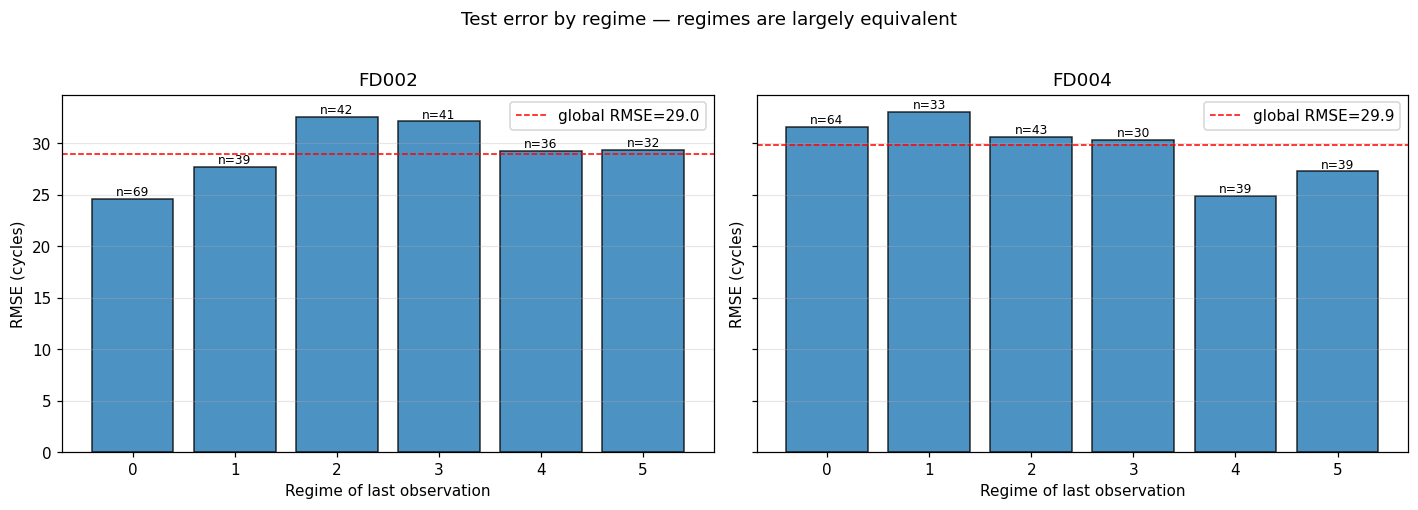

In [18]:
# ============= Plots =============
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
 
# 40. Per-regime RMSE bar chart (FD002 + FD004)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (ds, summary, total_rmse) in zip(axes, [
    ("FD002", sum2, r2['metrics']['RMSE']),
    ("FD004", sum4, r4['metrics']['RMSE']),
]):
    bars = ax.bar(summary.index.astype(str), summary["rmse"],
                  color="tab:blue", edgecolor="black", alpha=0.8)
    ax.axhline(total_rmse, color="red", ls="--", lw=1,
               label=f"global RMSE={total_rmse:.1f}")
    for b, n in zip(bars, summary["n"]):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f"n={n}", ha="center", fontsize=8)
    ax.set_xlabel("Regime of last observation")
    ax.set_ylabel("RMSE (cycles)")
    ax.set_title(f"{ds}")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("Test error by regime — regimes are largely equivalent",
             y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "40_error_by_regime.png", bbox_inches="tight")
plt.show()
plt.close()

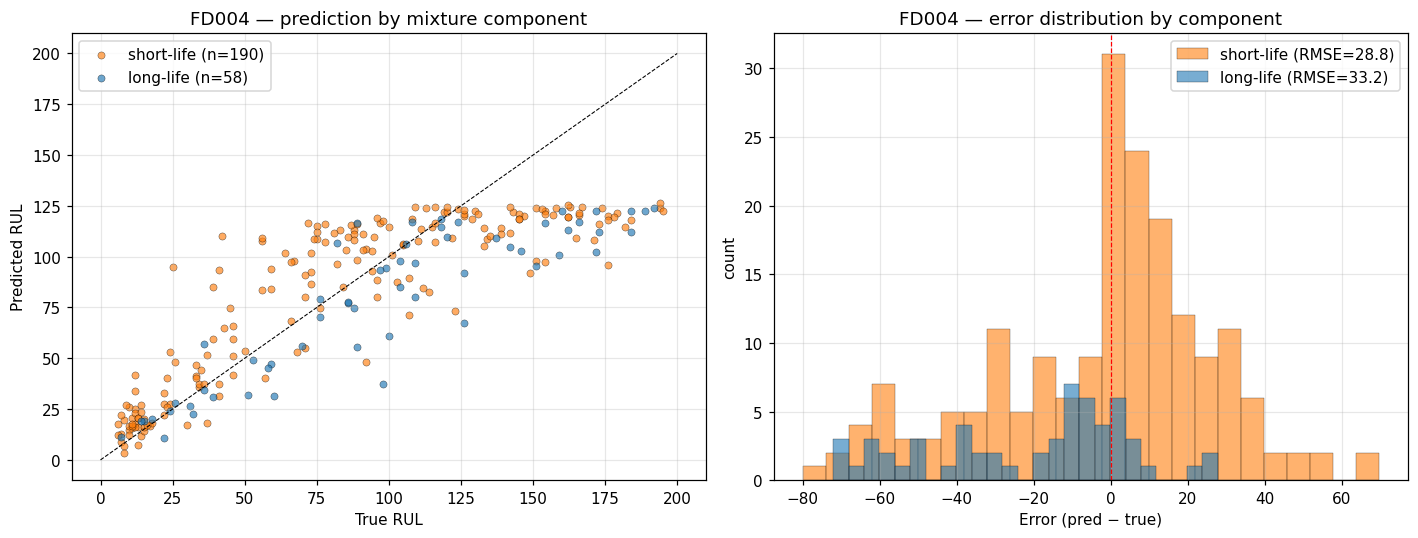

In [19]:
# 41. FD004: true vs predicted colored by mixture component
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ax = axes[0]
for comp, c in [("short-life", "tab:orange"), ("long-life", "tab:blue")]:
    m = df4["component"] == comp
    ax.scatter(df4.loc[m, "true"], df4.loc[m, "pred"],
               alpha=0.65, s=22, edgecolor="black", lw=0.3,
               label=f"{comp} (n={m.sum()})", color=c)
lim = max(df4["true"].max(), df4["pred"].max()) + 5
ax.plot([0, lim], [0, lim], "k--", lw=0.7)
ax.set_xlabel("True RUL")
ax.set_ylabel("Predicted RUL")
ax.set_title("FD004 — prediction by mixture component")
ax.legend()
ax.grid(alpha=0.3)
 
ax = axes[1]
for comp, c in [("short-life", "tab:orange"), ("long-life", "tab:blue")]:
    m = df4["component"] == comp
    ax.hist(df4.loc[m, "err"], bins=25, alpha=0.6, color=c,
            label=f"{comp} (RMSE={np.sqrt((df4.loc[m,'err']**2).mean()):.1f})",
            edgecolor="black", lw=0.3)
ax.axvline(0, color="red", ls="--", lw=0.8)
ax.set_xlabel("Error (pred − true)")
ax.set_ylabel("count")
ax.set_title("FD004 — error distribution by component")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "41_error_by_component.png", bbox_inches="tight")
plt.show()
plt.close()

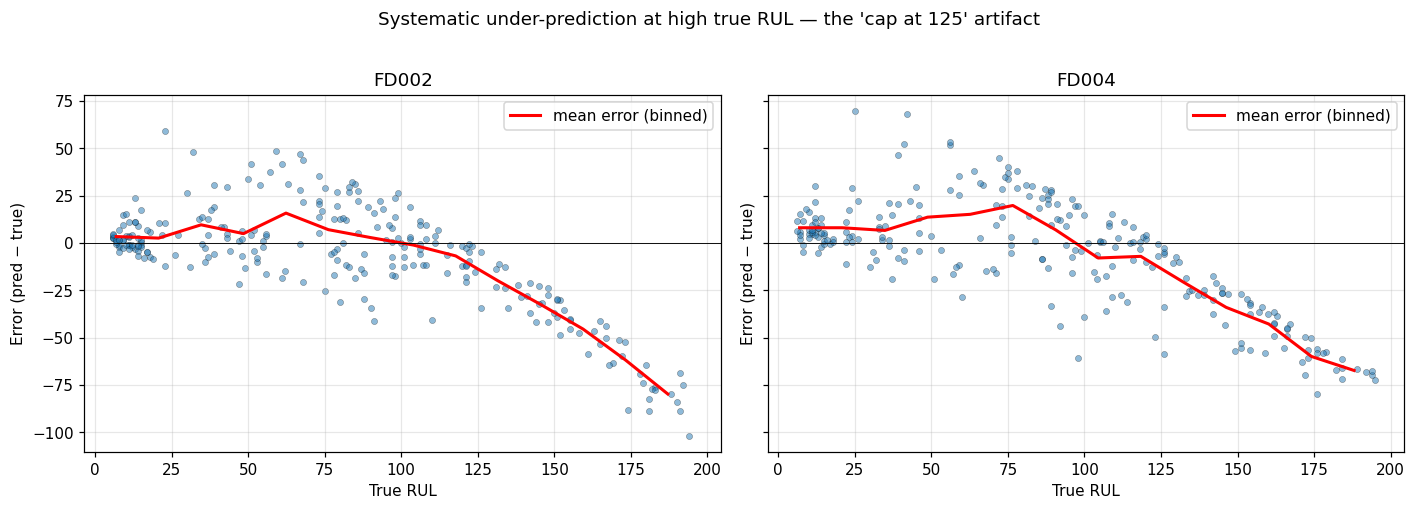

In [20]:
# 42. Error vs true RUL, with trend
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, (ds, df) in zip(axes, [("FD002", df2), ("FD004", df4)]):
    ax.scatter(df["true"], df["err"], alpha=0.5, s=16, edgecolor="black", lw=0.3)
    # local trend (loess-ish: moving avg by bins)
    bins = np.linspace(0, df["true"].max(), 15)
    bcenters = (bins[:-1] + bins[1:]) / 2
    means = [df.loc[(df["true"] >= bins[i]) & (df["true"] < bins[i+1]), "err"].mean()
             for i in range(len(bcenters))]
    ax.plot(bcenters, means, "r-", lw=2, label="mean error (binned)")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Error (pred − true)")
    ax.set_title(ds)
    ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle("Systematic under-prediction at high true RUL — the 'cap at 125' artifact",
             y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "42_error_vs_truerul.png", bbox_inches="tight")
plt.show()
plt.close()

In [21]:
pd.concat({"FD002_by_regime": sum2, "FD004_by_regime": sum4,
           "FD004_by_component": comp_sum}).to_csv("error_diagnostic.csv")